In [87]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [88]:
from PyPOTS_gp_benchmark_helpers import artifical_GP_generation

dataset_train_nan, dataset_val_nan, dataset_train, dataset_val, X_normalized, X = artifical_GP_generation(n_observations_per_group = 500,
                                                n_dimensions = 3,
                                                n_time_points = 30,
                                                n_new_dims = 3,
                                                p_dataset = 0.7)

100%|███████████████████████████████████████| 500/500 [00:00<00:00, 2660.07it/s]


In [89]:
import sys
sys.path.append("..")

In [91]:

# Model training. This is PyPOTS showtime.
from pypots.imputation import GP_UAE
from pypots.utils.metrics import calc_mae
from pypots.optim.adam import Adam
from torch.optim.lr_scheduler import LRScheduler

gpuae = GP_UAE(n_steps = dataset_train['X'].shape[1], 
            n_features = dataset_train['X'].shape[2], 
            latent_size = 6, 
            epochs = 300, 
            batch_size = 64,
            beta = 1., 
            K = 5,  
            encoder_sizes = (256,128,), 
            decoder_sizes = (128,128,),
            optimizer = Adam(weight_decay=0.001), #lr = 1e-4
            patience = 30,
            p = 0.1
            )

gpuae.model.backbone.alpha = 1e0
gpuae.model.backbone.beta = 1e-10
gpuae.model.backbone.gamma = 1e-10
gpuae.model.backbone.sigma1 = 1e-3
gpuae.model.backbone.sigma2 = 1e-1

gpuae.model.backbone.sampling = True
gpuae.model.backbone.use_mean = True
gpuae.model.backbone.noise_std = 1e-2
gpuae.model.backbone.detach = True
gpuae.model.backbone.compensate = False
gpuae.use_gp = False
gpuae.train_gp = False
gpuae.gp.plot_while_training = True

gpuae.model.backbone.p = 0.3
gpuae.model.backbone.device = 'cpu'

import torch
with torch.autograd.set_detect_anomaly(True):
    gpuae.fit(dataset_train_nan, dataset_val_nan)  # train the model on the dataset

2025-03-15 22:28:30 [INFO]: No given device, using default device: cpu
2025-03-15 22:28:30 [WARNING]: ‼️ saving_path not given. Model files and tensorboard file will not be saved.
2025-03-15 22:28:30 [INFO]: GP_UAE initialized with the given hyperparameters, the number of trainable parameters: 54,031


Model dimensions is:
GpvaeEncoder(
  (net): Sequential(
    (0): Linear(in_features=6, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): LeakyReLU(negative_slope=0.01)
  )
  (mu_layer): Linear(in_features=128, out_features=6, bias=True)
  (logvar_layer): Linear(in_features=128, out_features=6, bias=True)
)
GpvaeDecoder(
  (net): Sequential(
    (0): Linear(in_features=6, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=3, bias=True)
  )
)


2025-03-15 22:28:31 [INFO]: Epoch 001 - training loss: 309.7521, validation loss: 287.7491
2025-03-15 22:28:31 [INFO]: Epoch 002 - training loss: 237.1703, validation loss: 161.4186
2025-03-15 22:28:32 [INFO]: Epoch 003 - training loss: 95.1270, validation loss: 32.6114
2025-03-15 22:28:32 [INFO]: Epoch 004 - training loss: 40.8963, validation loss: 40.1058
2025-03-15 22:28:33 [INFO]: Epoch 005 - training loss: 22.8104, validation loss: 14.7230
2025-03-15 22:28:34 [INFO]: Epoch 006 - training loss: 16.0142, validation loss: 11.8764
2025-03-15 22:28:34 [INFO]: Epoch 007 - training loss: 9.4390, validation loss: 8.5801
2025-03-15 22:28:35 [INFO]: Epoch 008 - training loss: 7.6399, validation loss: 5.5574
2025-03-15 22:28:36 [INFO]: Epoch 009 - training loss: 5.2990, validation loss: 4.9407
2025-03-15 22:28:36 [INFO]: Epoch 010 - training loss: 4.3723, validation loss: 3.9583
2025-03-15 22:28:37 [INFO]: Epoch 011 - training loss: 3.7468, validation loss: 3.1296
2025-03-15 22:28:38 [INFO]:

Plotting latent series and reconstruction...


2025-03-15 22:29:11 [INFO]: Epoch 056 - training loss: 0.1036, validation loss: 0.0918
2025-03-15 22:29:12 [INFO]: Epoch 057 - training loss: 0.0768, validation loss: 0.0418
2025-03-15 22:29:12 [INFO]: Epoch 058 - training loss: 0.0605, validation loss: 0.0614
2025-03-15 22:29:13 [INFO]: Epoch 059 - training loss: 0.0553, validation loss: 0.0379
2025-03-15 22:29:13 [INFO]: Epoch 060 - training loss: 0.0366, validation loss: 0.0151
2025-03-15 22:29:14 [INFO]: Epoch 061 - training loss: 0.0168, validation loss: -0.0040
2025-03-15 22:29:15 [INFO]: Epoch 062 - training loss: -0.0078, validation loss: -0.0149
2025-03-15 22:29:15 [INFO]: Epoch 063 - training loss: -0.0172, validation loss: -0.0510
2025-03-15 22:29:16 [INFO]: Epoch 064 - training loss: -0.0343, validation loss: -0.0647
2025-03-15 22:29:16 [INFO]: Epoch 065 - training loss: -0.0538, validation loss: -0.0703
2025-03-15 22:29:17 [INFO]: Epoch 066 - training loss: -0.0657, validation loss: -0.0830
2025-03-15 22:29:18 [INFO]: Epoc

...

Plotting latent series and reconstruction...


2025-03-15 22:30:48 [INFO]: Epoch 223 - training loss: -0.8407, validation loss: -0.8308
2025-03-15 22:30:48 [INFO]: Epoch 224 - training loss: -0.8472, validation loss: -0.8433
2025-03-15 22:30:49 [INFO]: Epoch 225 - training loss: -0.8619, validation loss: -0.8968
2025-03-15 22:30:50 [INFO]: Epoch 226 - training loss: -0.8741, validation loss: -0.8887
2025-03-15 22:30:50 [INFO]: Epoch 227 - training loss: -0.8820, validation loss: -0.8875
2025-03-15 22:30:51 [INFO]: Epoch 228 - training loss: -0.8817, validation loss: -0.8961
2025-03-15 22:30:52 [INFO]: Epoch 229 - training loss: -0.8943, validation loss: -0.9186
2025-03-15 22:30:53 [INFO]: Epoch 230 - training loss: -0.8969, validation loss: -0.9144
2025-03-15 22:30:53 [INFO]: Epoch 231 - training loss: -0.8905, validation loss: -0.9026
2025-03-15 22:30:54 [INFO]: Epoch 232 - training loss: -0.8954, validation loss: -0.9159
2025-03-15 22:30:54 [INFO]: Epoch 233 - training loss: -0.9008, validation loss: -0.9081
2025-03-15 22:30:55 [

Plotting latent series and reconstruction...


2025-03-15 22:31:20 [INFO]: Epoch 278 - training loss: -0.9083, validation loss: -0.9479
2025-03-15 22:31:20 [INFO]: Epoch 279 - training loss: -0.9150, validation loss: -0.9263
2025-03-15 22:31:21 [INFO]: Epoch 280 - training loss: -0.9082, validation loss: -0.9325
2025-03-15 22:31:21 [INFO]: Epoch 281 - training loss: -0.9144, validation loss: -0.8619
2025-03-15 22:31:21 [INFO]: Epoch 282 - training loss: -0.8718, validation loss: -0.9208
2025-03-15 22:31:22 [INFO]: Epoch 283 - training loss: -0.9089, validation loss: -0.9142
2025-03-15 22:31:23 [INFO]: Epoch 284 - training loss: -0.9067, validation loss: -0.9282
2025-03-15 22:31:24 [INFO]: Epoch 285 - training loss: -0.9046, validation loss: -0.8682
2025-03-15 22:31:24 [INFO]: Epoch 286 - training loss: -0.7684, validation loss: -0.8606
2025-03-15 22:31:25 [INFO]: Epoch 287 - training loss: -0.8189, validation loss: -0.8346
2025-03-15 22:31:25 [INFO]: Epoch 288 - training loss: -0.8484, validation loss: -0.8581
2025-03-15 22:31:26 [

training kernel


In [69]:
gpuae_no_sampling = gpuae


=== Evaluating GPUAE_sampling ===

RMSE: 0.2068
NLL: -581.8248
ELBO: -155776.8627

=== Evaluating GPUAE_no_sampling ===

RMSE: 0.2326
NLL: 1195.1642
ELBO: -255886.0079


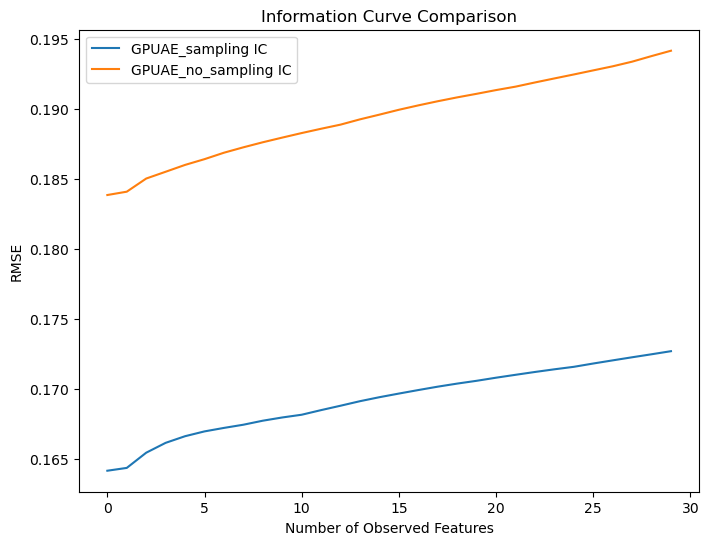

In [86]:
import numpy as np
import torch
import torch.distributions as dist
import matplotlib.pyplot as plt

# ==========================
# 🚀 Utility Functions
# ==========================

def compute_rmse(true_data, imputed_data, missing_mask):
    """
    Compute RMSE between imputed and true values, considering only missing values.
    """
    missing_values = missing_mask.astype(bool)
    mse = np.mean((true_data[missing_values] - imputed_data[missing_values]) ** 2)
    return np.sqrt(mse)

def compute_nll(recon_mu, recon_var, true_data, missing_mask):
    """
    Compute the Negative Log-Likelihood (NLL) for missing values.
    """
    missing_values = missing_mask.astype(bool)
    recon_var = np.clip(recon_var, 1e-6, None)  # Avoid division by zero
    nll = 0.5 * np.sum(
        (true_data[missing_values] - recon_mu[missing_values])**2 / recon_var[missing_values]
        + np.log(recon_var[missing_values]) + np.log(2 * np.pi)
    )
    return nll

def compute_kl_divergence(q_mu, q_var, p_mu=0, p_var=1):
    """
    Compute KL divergence between approximate posterior q(z|x) and prior p(z).
    """
    q_dist = dist.Normal(q_mu, torch.sqrt(q_var))
    p_dist = dist.Normal(p_mu, torch.sqrt(torch.tensor(p_var)))
    kl_div = torch.distributions.kl_divergence(q_dist, p_dist)
    return kl_div.sum().item()

def compute_information_curve(X_true, X_imputed, missing_mask):
    """
    Compute the Information Curve (IC) by iteratively adding the most informative feature.
    """
    n_features = X_true.shape[1]
    observed_mask = np.zeros_like(missing_mask, dtype=bool)
    info_curve = []

    for _ in range(n_features):
        best_feature = None
        best_rmse = float('inf')

        for feature in range(n_features):
            if observed_mask[:, feature].any():  # Skip if already observed
                continue

            temp_mask = observed_mask.copy()
            temp_mask[:, feature] = True

            rmse = compute_rmse(X_true, X_imputed, temp_mask)
            if rmse < best_rmse:
                best_rmse = rmse
                best_feature = feature

        observed_mask[:, best_feature] = True
        info_curve.append(best_rmse)

    return info_curve

# ==========================
# 🚀 Benchmarking Function
# ==========================

def benchmark_models(models, model_names, X, missing_mask):
    """
    Compare two models on RMSE, NLL, ELBO, and IC.
    
    Parameters:
    - models (list): List containing two trained models [gpvae, gpvae2].
    - model_names (list): List of model names for display.
    - X (numpy array): Input data (ground truth).
    - missing_mask (numpy array): Binary mask (1 = missing, 0 = observed).
    
    Returns:
    - Dictionary with evaluation results.
    """
    results = {}

    for i, model in enumerate(models):
        print(f"\n=== Evaluating {model_names[i]} ===\n")

        # Encode & Decode
        qz_x = model.model.backbone.encode(torch.tensor(X).float())
        z = qz_x.rsample()
        z = qz_x.mean
        X_recon = np.array(model.model.backbone.decode(z).mean.detach().numpy())

        # Compute Metrics
        rmse = compute_rmse(X, X_recon, missing_mask)
        nll = compute_nll(X_recon, np.ones_like(X_recon) * 0.1, X, missing_mask)
        kl_div = compute_kl_divergence(qz_x.mean.detach(), qz_x.variance.detach())
        elbo = -nll - kl_div
        info_curve = compute_information_curve(X, X_recon, missing_mask)

        # Store Results
        results[model_names[i]] = {
            "RMSE": rmse,
            "NLL": nll,
            "ELBO": elbo,
            "Information Curve": info_curve
        }

        # Print Results
        print(f"RMSE: {rmse:.4f}")
        print(f"NLL: {nll:.4f}")
        print(f"ELBO: {elbo:.4f}")

    # ==========================
    # 🚀 Plot Information Curves
    # ==========================
    plt.figure(figsize=(8,6))
    for i, model_name in enumerate(model_names):
        plt.plot(results[model_name]["Information Curve"], label=f"{model_name} IC")
    
    plt.xlabel("Number of Observed Features")
    plt.ylabel("RMSE")
    plt.legend()
    plt.title("Information Curve Comparison")
    plt.show()

    return results

# ==========================
# 🚀 Run Benchmarking
# ==========================

# Define models and names
models = [gpuae, gpuae_no_sampling]
model_names = ["GPUAE_sampling", "GPUAE_no_sampling"]

# Identify missing values
missing_mask = (X == 0)

# Run Benchmark
results = benchmark_models(models, model_names, X, missing_mask)



In [54]:
torch.save(gpuae.model.backbone.encoder.state_dict().copy(), 'encoder_uae')
torch.save(gpuae.model.backbone.decoder.state_dict().copy(), 'decoder_uae')

In [56]:
state_dict = torch.load('encoder_uae');
gpuae.model.backbone.encoder.load_state_dict(state_dict);
state_dict = torch.load('decoder_uae');
gpuae.model.backbone.decoder.load_state_dict(state_dict);

/var/folders/7s/75p3d4f145qfrrzfq5vskssc0000gn/T/ipykernel_42907/1864936539.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load('encoder_uae');
/var/

2025-03-09 19:51:15 [INFO]: Epoch 001 - training loss: -0.2463, validation loss: -0.6238
2025-03-09 19:51:15 [INFO]: Epoch 002 - training loss: -0.4533, validation loss: -0.4693
2025-03-09 19:51:16 [INFO]: Epoch 003 - training loss: -0.5672, validation loss: -0.4798
2025-03-09 19:51:16 [INFO]: Epoch 004 - training loss: -0.6706, validation loss: -0.6882
2025-03-09 19:51:17 [INFO]: Epoch 005 - training loss: -0.7398, validation loss: -0.7934
2025-03-09 19:51:17 [INFO]: Epoch 006 - training loss: -0.8156, validation loss: -0.7724
2025-03-09 19:51:18 [INFO]: Epoch 007 - training loss: -0.8279, validation loss: -0.8100
2025-03-09 19:51:18 [INFO]: Epoch 008 - training loss: -0.8584, validation loss: -0.8087
2025-03-09 19:51:19 [INFO]: Epoch 009 - training loss: -0.8604, validation loss: -0.8504
2025-03-09 19:51:19 [INFO]: Epoch 010 - training loss: -0.8669, validation loss: -0.8419
2025-03-09 19:51:19 [INFO]: Epoch 011 - training loss: -0.8896, validation loss: -0.8436
2025-03-09 19:51:20 [

Plotting latent series and reconstruction...


2025-03-09 19:51:38 [INFO]: Epoch 054 - training loss: -0.8988, validation loss: -0.8676
2025-03-09 19:51:39 [INFO]: Epoch 055 - training loss: -0.8910, validation loss: -0.8566
2025-03-09 19:51:39 [INFO]: Epoch 056 - training loss: -0.9054, validation loss: -0.8708
2025-03-09 19:51:39 [INFO]: Epoch 057 - training loss: -0.8972, validation loss: -0.8641
2025-03-09 19:51:40 [INFO]: Epoch 058 - training loss: -0.9013, validation loss: -0.8787
2025-03-09 19:51:40 [INFO]: Epoch 059 - training loss: -0.9058, validation loss: -0.8629
2025-03-09 19:51:41 [INFO]: Epoch 060 - training loss: -0.9059, validation loss: -0.8865
2025-03-09 19:51:41 [INFO]: Epoch 061 - training loss: -0.8863, validation loss: -0.7643
2025-03-09 19:51:42 [INFO]: Epoch 062 - training loss: -0.6543, validation loss: -0.8270
2025-03-09 19:51:42 [INFO]: Epoch 063 - training loss: -0.8195, validation loss: -0.8039
2025-03-09 19:51:42 [INFO]: Epoch 064 - training loss: -0.8824, validation loss: -0.8432
2025-03-09 19:51:43 [

training kernel


1it [00:00,  7.22it/s]

...

4it [00:00,  7.31it/s]

197.70278930664062 11.20081901550293


6it [00:00,  8.01it/s]

188.4116668701172 9.198936462402344
torch.Size([64, 30, 3]) torch.Size([64, 30, 3])


torch.Size([64, 30, 3]) torch.Size([64, 30, 3])
torch.Size([22, 30, 3]) torch.Size([22, 30, 3])


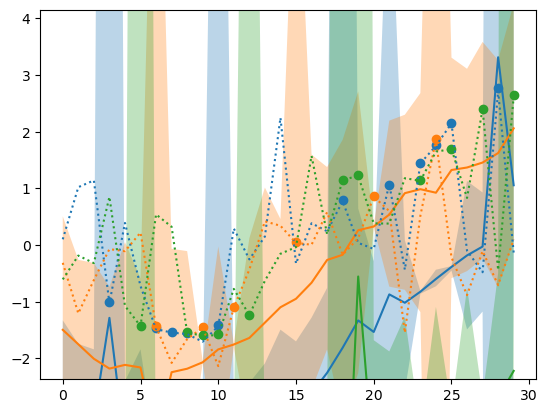

2025-03-09 19:51:56 [WARNING]: ‼️ Training got interrupted by the user. Exist now ...


AttributeError: 'GP_UAE' object has no attribute 'best_kernel_epoch'

In [157]:
gpuae.fit(dataset_train_nan, dataset_val_nan)  # train the model on the dataset

training kernel


0it [00:00, ?it/s]

0.0017557910177856684 0.08516504615545273


2it [00:00,  4.22it/s]

0.0018639633199200034 0.12925031781196594


...

0.002011997625231743 0.10602942109107971


5it [00:01,  4.26it/s]

0.001795420772396028 0.1155286654829979
0.0020742621272802353 0.17869728803634644


6it [00:01,  4.67it/s]


torch.Size([64, 30, 3]) torch.Size([64, 30, 3])
torch.Size([64, 30, 3]) torch.Size([64, 30, 3])
torch.Size([22, 30, 3]) torch.Size([22, 30, 3])


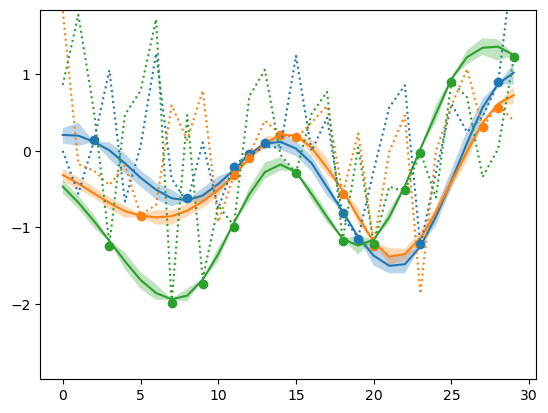

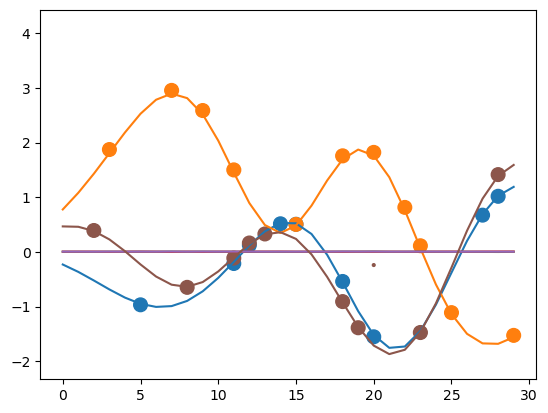

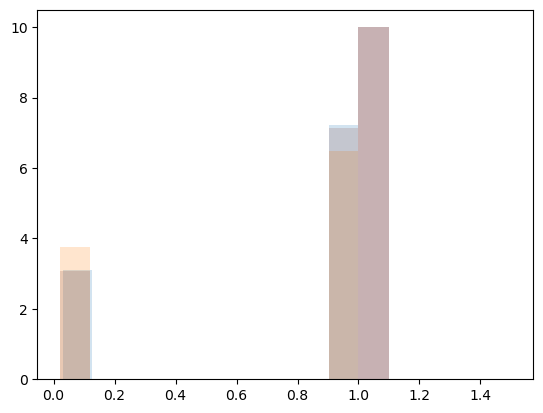

Epoch 2/300: Training Loss = 0.046399, Validation Loss = 0.149362


0it [00:00, ?it/s]

0.0018392855999991298 0.17955759167671204


2it [00:00,  4.79it/s]

0.0017842416418716311 0.13290399312973022


...

0.0017768819816410542 0.17657694220542908


5it [00:01,  4.67it/s]

0.0018496966222301126 0.14545667171478271
0.0018464872846379876 0.3613797426223755


6it [00:01,  5.13it/s]


torch.Size([64, 30, 3]) torch.Size([64, 30, 3])
torch.Size([64, 30, 3]) torch.Size([64, 30, 3])
torch.Size([22, 30, 3]) torch.Size([22, 30, 3])


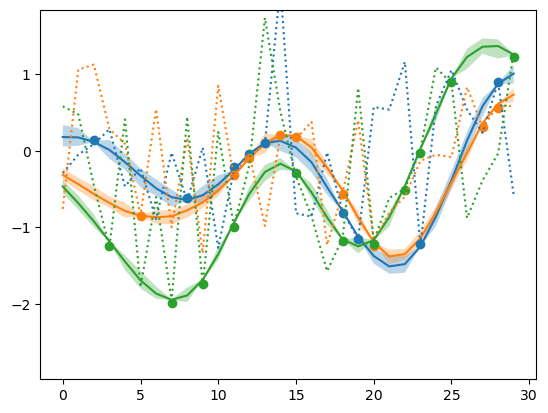

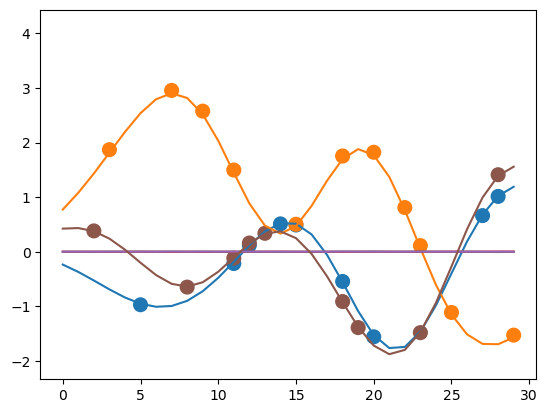

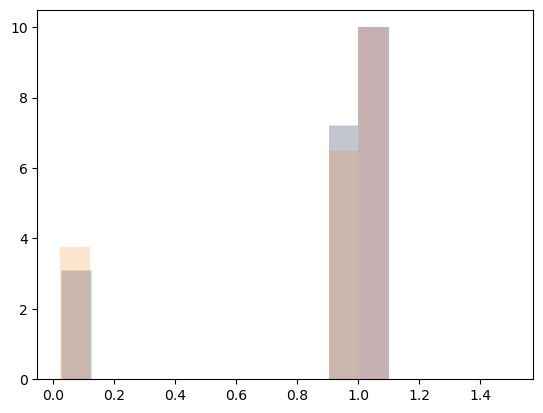

Epoch 3/300: Training Loss = 0.051783, Validation Loss = 0.144060


0it [00:00, ?it/s]

0.001543234451673925 0.1042158380150795


2it [00:00,  4.68it/s]

0.0017247748328372836 0.13932552933692932


...

0.0016523470403626561 0.14946238696575165


5it [00:01,  4.50it/s]

0.001957541098818183 0.1743788719177246
0.0015592215349897742 0.11056901514530182


6it [00:01,  4.99it/s]


torch.Size([64, 30, 3]) torch.Size([64, 30, 3])
torch.Size([64, 30, 3]) torch.Size([64, 30, 3])
torch.Size([22, 30, 3]) torch.Size([22, 30, 3])


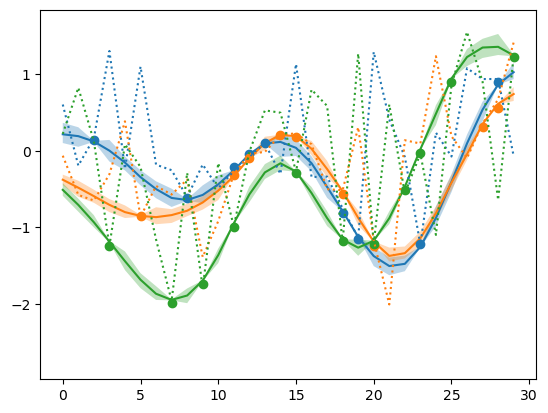

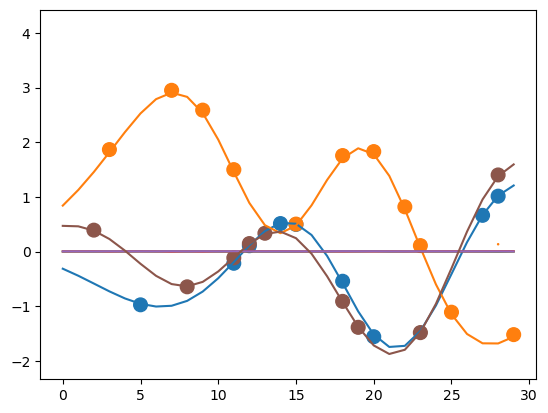

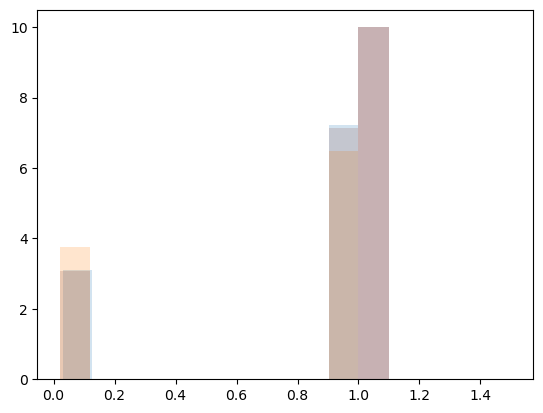

Epoch 4/300: Training Loss = 0.046974, Validation Loss = 0.142313


0it [00:00, ?it/s]

0.0018573966808617115 0.11219554394483566


2it [00:00,  4.20it/s]

0.0015423012664541602 0.10431839525699615


...

0.0018706012051552534 0.11751110106706619


5it [00:01,  4.54it/s]

0.002078707329928875 0.20370806753635406
0.0017627490451559424 0.17381833493709564


6it [00:01,  4.87it/s]


torch.Size([64, 30, 3]) torch.Size([64, 30, 3])
torch.Size([64, 30, 3]) torch.Size([64, 30, 3])
torch.Size([22, 30, 3]) torch.Size([22, 30, 3])


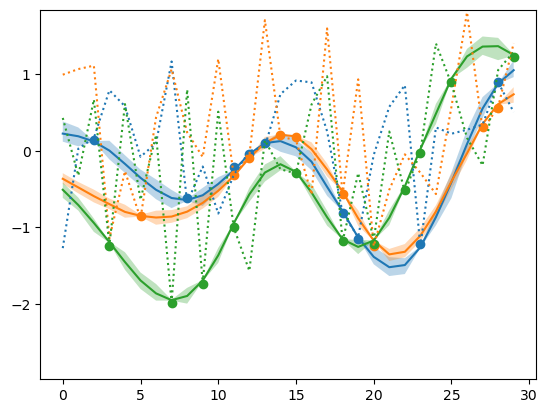

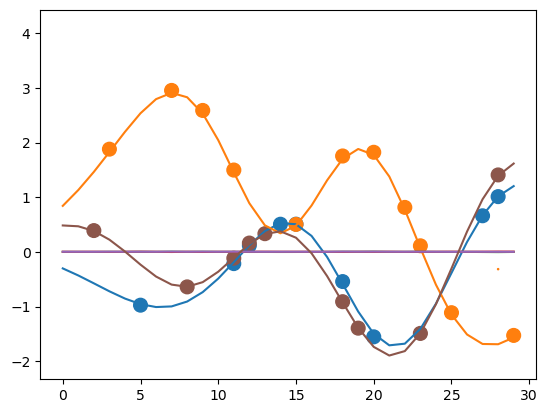

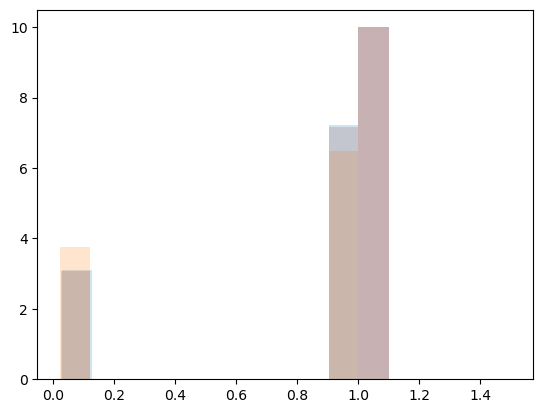

Epoch 5/300: Training Loss = 0.049637, Validation Loss = 0.162748


0it [00:00, ?it/s]

0.0016998917562887073 0.10832814872264862


2it [00:00,  4.63it/s]

0.0018165401415899396 0.08763141930103302


...

0.0020857052877545357 0.12103098630905151


5it [00:01,  4.61it/s]

0.0017670115921646357 0.18454910814762115
0.0018811372574418783 0.11032762378454208


6it [00:01,  5.05it/s]


torch.Size([64, 30, 3]) torch.Size([64, 30, 3])
torch.Size([64, 30, 3]) torch.Size([64, 30, 3])
torch.Size([22, 30, 3]) torch.Size([22, 30, 3])


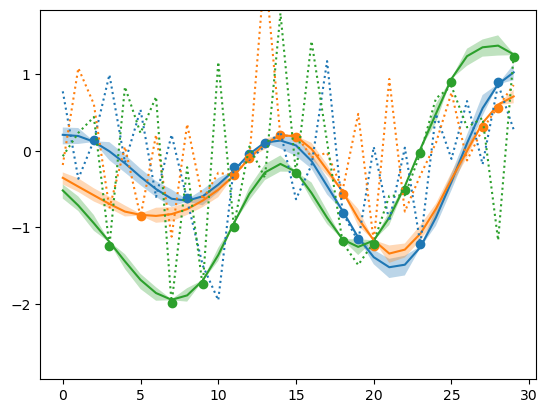

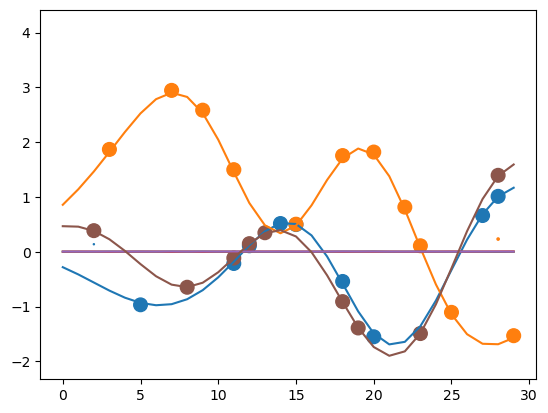

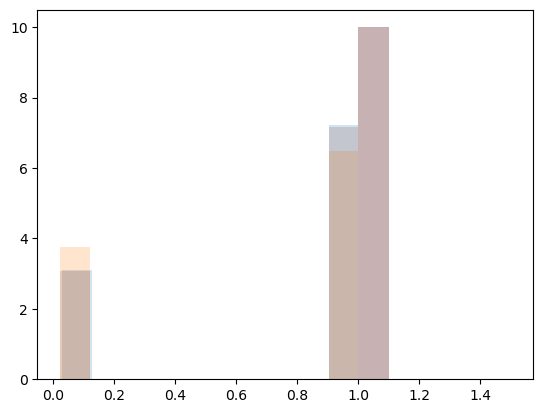

Epoch 6/300: Training Loss = 0.045768, Validation Loss = 0.158866


0it [00:00, ?it/s]

0.0017678315052762628 0.18797409534454346


2it [00:00,  3.48it/s]

0.0017578721744939685 0.13469773530960083


...

0.0021698439959436655 0.1099068820476532


5it [00:01,  4.29it/s]

0.0018409955082461238 0.20665836334228516
0.0015764872077852488 0.03253709524869919


6it [00:01,  4.56it/s]


torch.Size([64, 30, 3]) torch.Size([64, 30, 3])
torch.Size([64, 30, 3]) torch.Size([64, 30, 3])
torch.Size([22, 30, 3]) torch.Size([22, 30, 3])


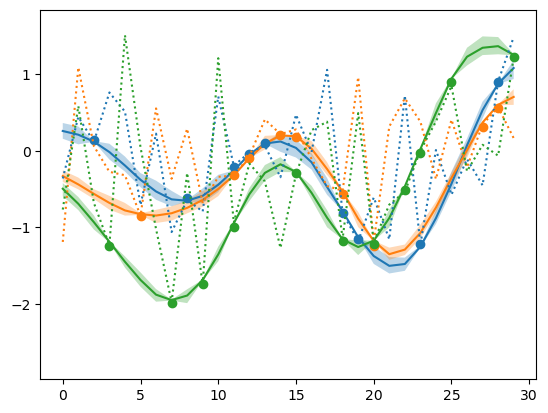

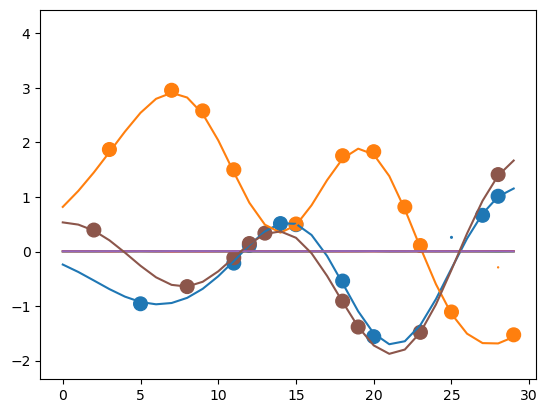

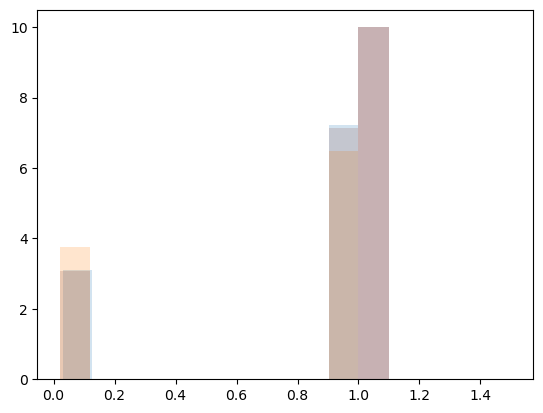

Epoch 7/300: Training Loss = 0.046755, Validation Loss = 0.150221


0it [00:00, ?it/s]

0.0017047259025275707 0.10420311242341995


2it [00:00,  4.59it/s]

0.001961784204468131 0.11491595208644867


...

0.001830619410611689 0.17766188085079193


5it [00:01,  4.62it/s]

0.0017483136616647243 0.20107771456241608
0.0019844986964017153 0.17612074315547943


6it [00:01,  5.04it/s]


torch.Size([64, 30, 3]) torch.Size([64, 30, 3])
torch.Size([64, 30, 3]) torch.Size([64, 30, 3])
torch.Size([22, 30, 3]) torch.Size([22, 30, 3])


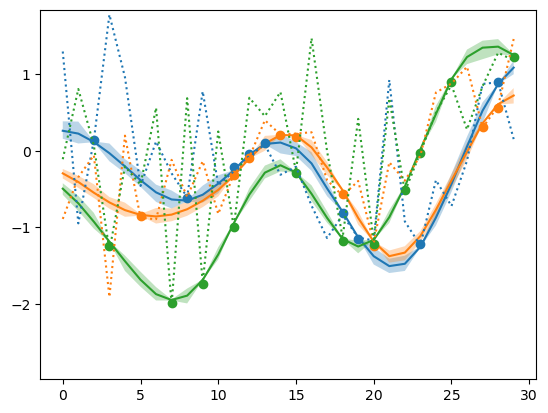

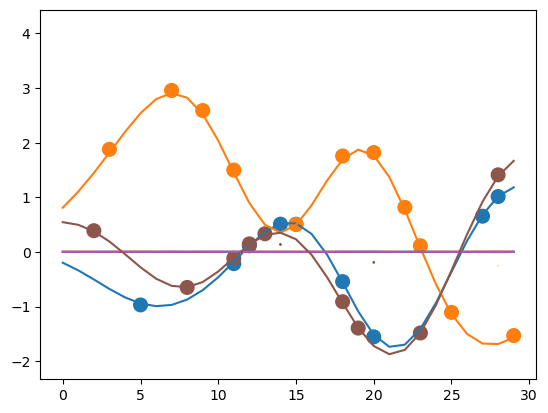

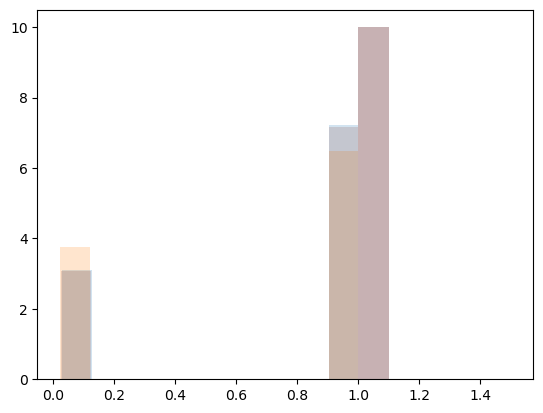

Epoch 8/300: Training Loss = 0.048107, Validation Loss = 0.157153


0it [00:00, ?it/s]

0.0019394629634916782 0.09697255492210388


2it [00:00,  4.72it/s]

0.0019846325740218163 0.09259895980358124


...

4it [00:00,  4.63it/s]

0.001999831525608897 0.11393096297979355


5it [00:01,  4.67it/s]

0.0018026212928816676 0.1913529485464096
0.0018110251985490322 0.170404314994812


5it [00:01,  4.26it/s]
2025-03-15 22:48:17 [WARNING]: ‼️ Training got interrupted by the user. Exist now ...
2025-03-15 22:48:17 [INFO]: Finished training. The best model is from epoch#3.


In [108]:
#gpuae.model.backbone.alpha = 1e0
gpuae_no_sampling.gp.p = 0.1

gpuae.fit(dataset_train_nan, dataset_val_nan, train_kernel_only = True)  # train the model on the dataset

In [ ]:
gpuae.gp.kernel_params_history[5]['e'][900]

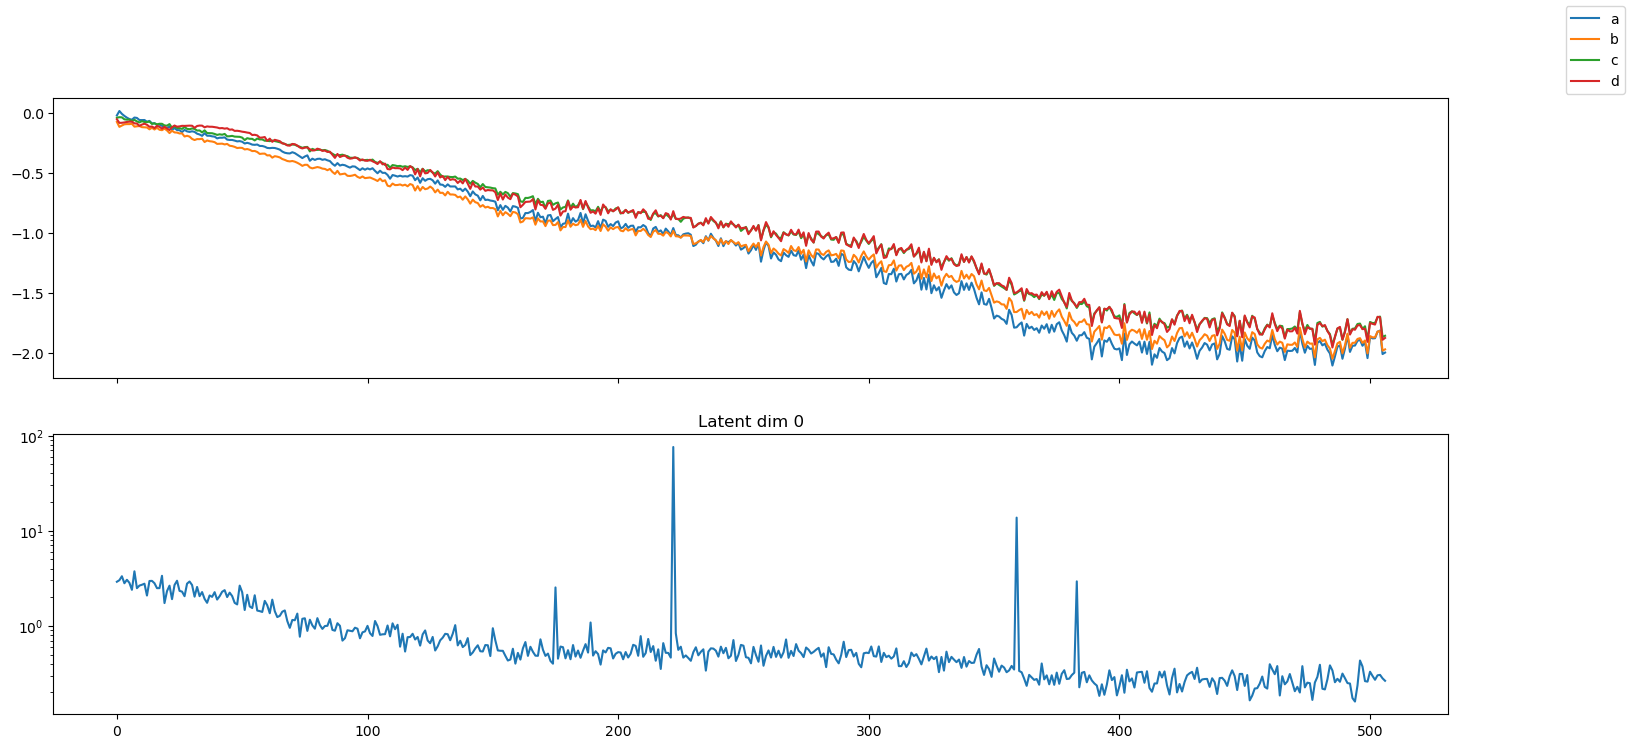

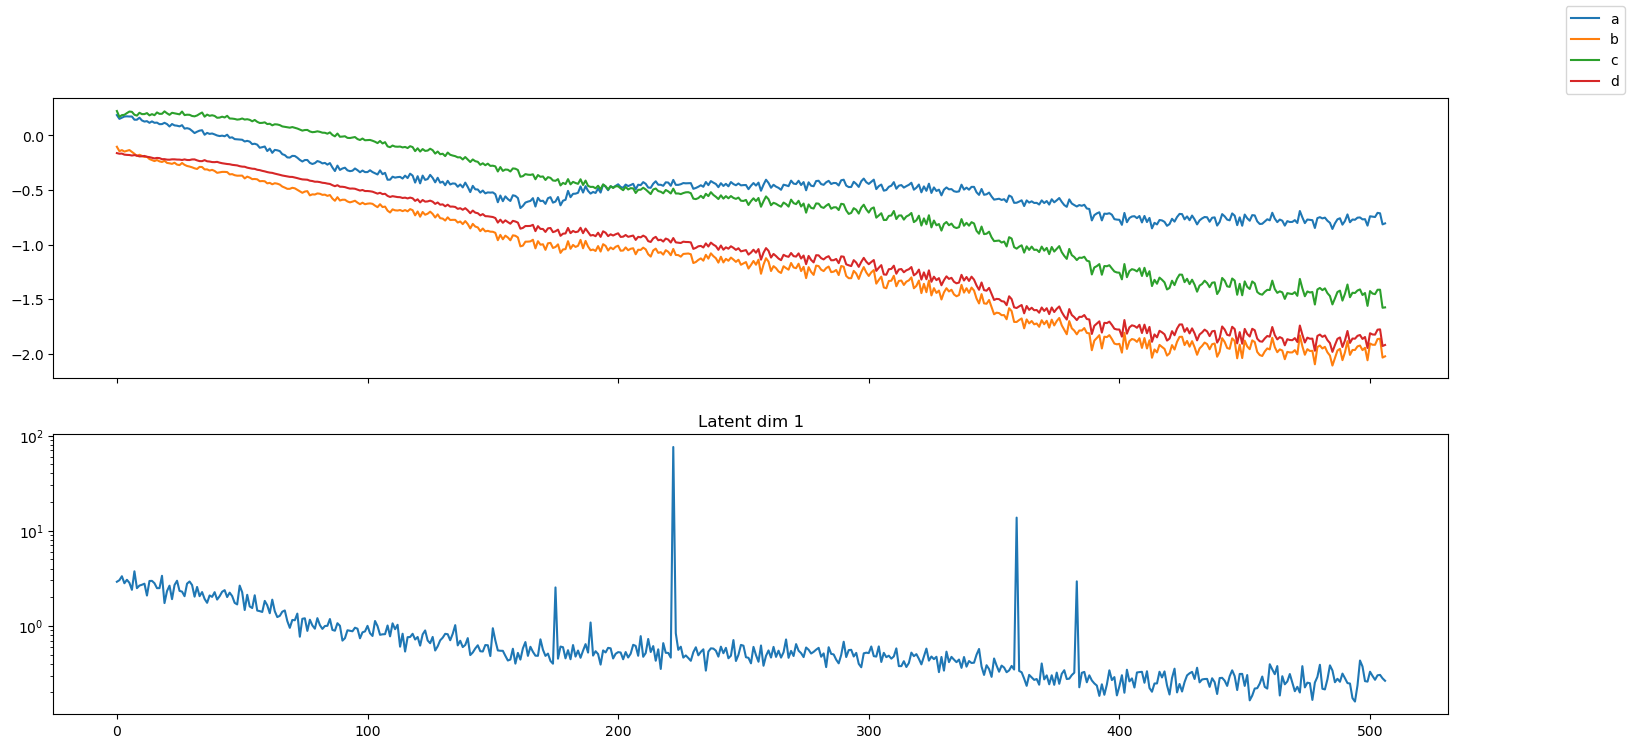

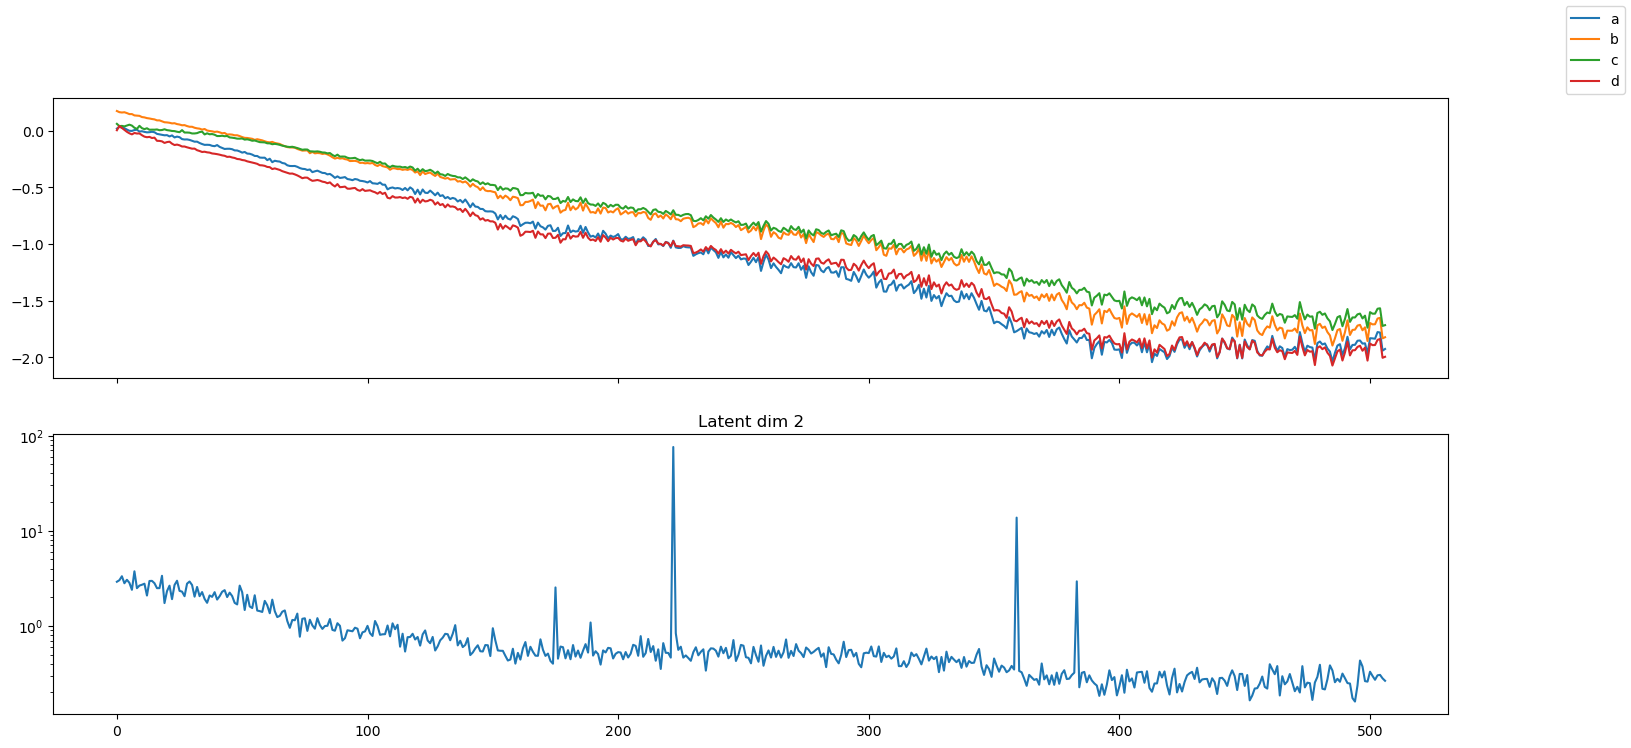

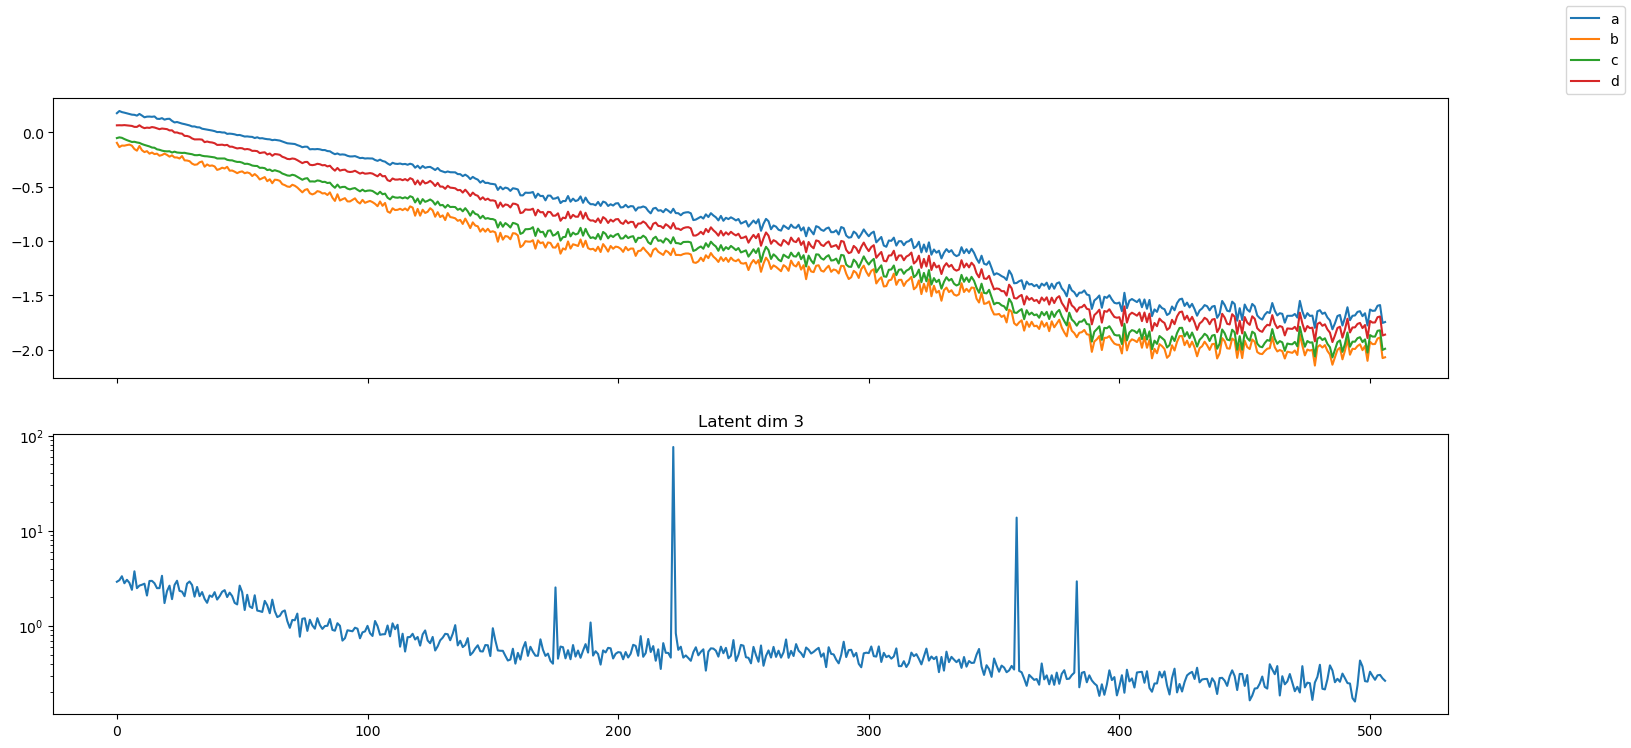

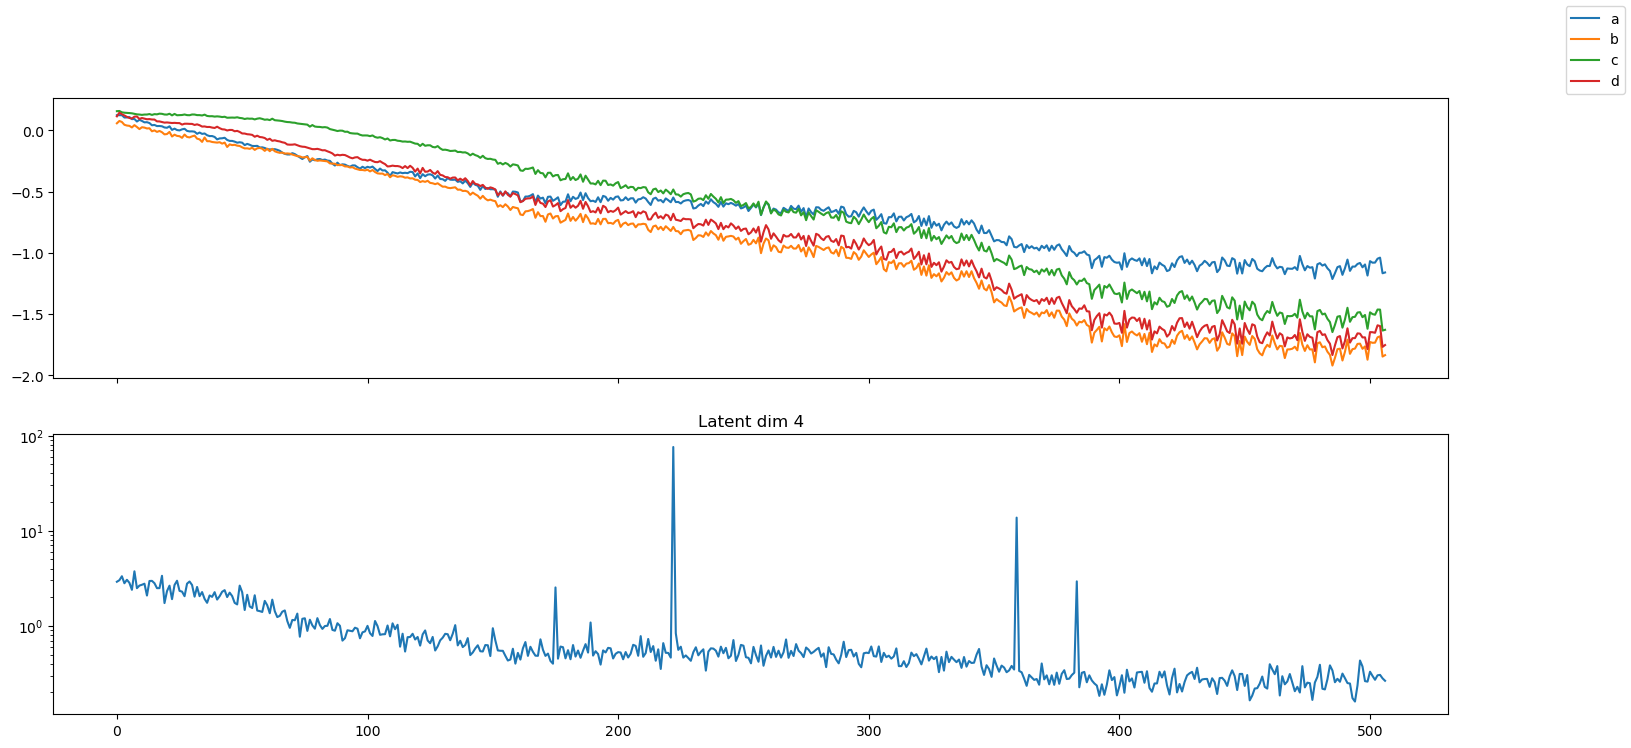

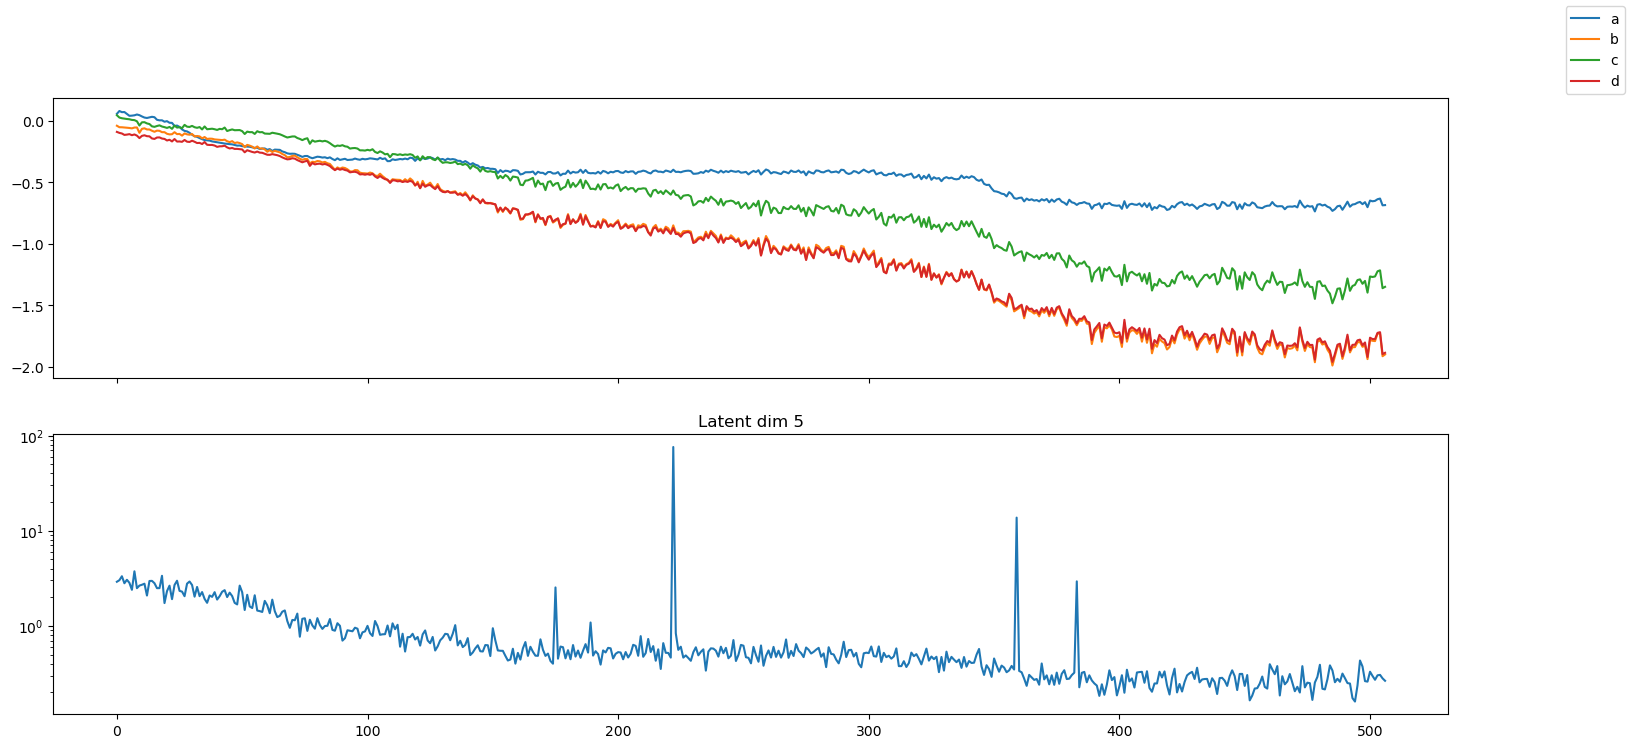

In [48]:
import matplotlib.pyplot as plt

for j in gpuae.gp.kernel_params_history.keys():
    hist_j = gpuae.gp.kernel_params_history[j]
    fig, ax = plt.subplots(2, figsize=(18,8), sharex = True)
    for elt in ['a','b','c','d']:
        ax[0].plot(hist_j[elt], label = elt)
    ax[1].semilogy(hist_j['e'])
    fig.legend();
    plt.title(f'Latent dim {j}')
    plt.show();

In [ ]:

# Model training. This is PyPOTS showtime.
from pypots.imputation import GP_VAE
from pypots.utils.metrics import calc_mae
from pypots.optim.adam import Adam
from torch.optim.lr_scheduler import LRScheduler

gpvae = GP_VAE(n_steps = dataset_train['X'].shape[1], 
            n_features = dataset_train['X'].shape[2], 
            latent_size = 10, 
            epochs = 300, 
            batch_size = 64,
            beta = 1., 
            K = 5,  
            encoder_sizes = (128,128), 
            decoder_sizes = (256,256),
            optimizer = Adam(weight_decay=0.001), #lr = 1e-4
            patience = 30
            )

gpvae.model.backbone.alpha = 1e0
gpvae.model.backbone.beta = 1e-2
gpvae.model.backbone.gamma = 5 * 1e-5
gpvae.model.backbone.sigma1 = 1e-3
gpvae.model.backbone.sigma2 = 1e-2

gpvae.model.backbone.sampling = True
gpvae.model.backbone.use_mean = True
gpvae.model.backbone.noise_std = 1e-2
gpvae.model.backbone.detach = True
gpvae.model.backbone.compensate = False
gpvae.use_gp = False
gpvae.train_gp = False
gpvae.gp.plot_while_training = True

gpvae.model.backbone.p = 0.3
gpvae.model.backbone.device = 'cpu'

import torch
with torch.autograd.set_detect_anomaly(True):
    gpvae.fit(dataset_train_nan, dataset_val_nan)  # train the model on the dataset

In [23]:
kernel_params.shape

torch.Size([2, 10, 5])

In [36]:
import numpy as np
ls = 10. ** np.arange(-3,2)
sigma = 10. ** np.arange(-3,2)
noise = 10. ** np.arange(-3,2)
vi = 10. ** np.arange(-3,2)
vi2 = 10. ** np.arange(-3,2)

errs = {}

from tqdm import tqdm

for a in tqdm(ls):
    for b in sigma:
        for c in noise:
            for d in vi:
                for e in vi2:
                    
                    with torch.no_grad():
                        X_ori = torch.tensor(dataset_val['X_ori'][0])
                        X = torch.tensor(dataset_val['X'][:2])
                        missing_mask = (X!=0)
                    
                        qz_x = gpuae.model.backbone.encode(X, missing_mask)
                        kernel_params = gpuae.gp.update_kernel_params(X)
                        q_star = gpuae.gp.correct_qz_x_with_gp(qz_x, X)

                        z_ = q_star.rsample((100,))

                        X_recon = gpuae.model.backbone.decode(z_).mean[:,0]

                        l2 = (X_ori.unsqueeze(0) - X_recon).pow(2).mean()

                        errs[(a, b, c, d, e)] = l2.item()
     
                    
                        #gpuae.gp.plot_latent_GP_regression(q_star, qz_x, X)

100%|█████████████████████████████████████████████| 5/5 [00:21<00:00,  4.24s/it]


In [37]:
# Find the best hyperparameter combination (lowest L2 loss)
best_params = min(errs, key=errs.get)
print("Best hyperparameters:", best_params, "with loss:", errs[best_params])

Best hyperparameters: (1.0, 0.001, 0.1, 0.01, 0.001) with loss: 19.991010665893555


In [205]:
plt.plot(np.array(X_ori.detach().numpy()));
plt.gca().set_prop_cycle(None)
plt.plot(np.array(X_recon[0].detach().numpy()),'o');

NameError: name 'X_ori' is not defined

In [ ]:
gpvae.use_gp = True
gpvae.train_gp = True
gpvae.gp.plot_while_training = True

gpvae.model.backbone.p = 0.3
gpvae.model.p = 0.3

gpvae.model.backbone.device = 'cpu'

import torch
with torch.autograd.set_detect_anomaly(True):
    gpvae.fit(dataset_train_nan, dataset_val_nan)  # train the model on the dataset

In [ ]:
gpvae.fit(dataset_train_nan, dataset_val_nan)  # train the model on the dataset

In [ ]:
gpvae.gp.plot_while_training = True
gpvae.gp.alpha = 0.01
gpvae.fit_kernel(dataset_train, dataset_val, training_iter = 50)  # train the model on the dataset

In [ ]:
gpvae.gp.p

In [107]:
from pypots.utils.metrics import calc_mae
import numpy as np

results = gpuae.predict(dataset_val_nan, with_gp = True)
imputation = np.array(results['imputation'])
calc_mae(imputation, dataset_val_nan['X_ori'], (dataset_val_nan['X_ori']==dataset_val_nan['X_ori']))

0.23765463647182067

In [100]:
from pypots.utils.metrics import calc_mae
import numpy as np

results = saits.predict(dataset_val_nan)
imputation = np.array(results['imputation'])
calc_mae(imputation, dataset_val_nan['X_ori'], (dataset_val_nan['X_ori']==dataset_val_nan['X_ori']))

0.2181900284192237

In [ ]:
from pypots.utils.metrics import calc_mae
import numpy as np

results = gp_vae.predict(dataset_val_nan)
imputation = np.array(results['imputation']).squeeze(1)
calc_mae(imputation, dataset_val_nan['X_ori'], (dataset_val_nan['X_ori']==dataset_val_nan['X_ori']))

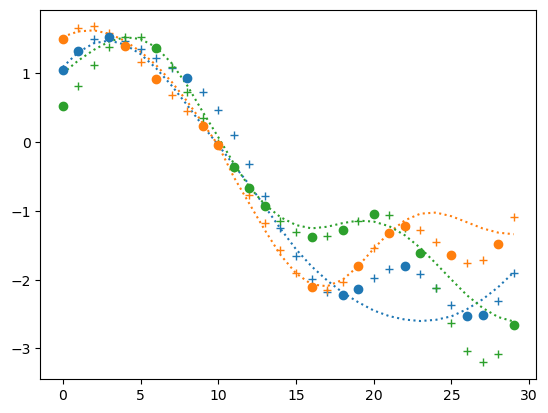

In [103]:
import matplotlib.pyplot as plt
plt.plot(imputation[0],':');
plt.gca().set_prop_cycle(None)
plt.plot(dataset_val_nan['X_ori'][0],'+');
plt.gca().set_prop_cycle(None)
plt.plot(dataset_val_nan['X'][0],'o');

In [ ]:
from pypots.imputation import CSDI

# initialize the model
csdi = CSDI(
    n_steps=30,
    n_features=5,
    n_layers=6,
    n_heads=2,
    n_channels=128,
    d_time_embedding=64,
    d_feature_embedding=32,
    d_diffusion_embedding=128,
    target_strategy="random",
    n_diffusion_steps=50,
    batch_size=32,
    # here we set epochs=10 for a quick demo, you can set it to 100 or more for better performance
    epochs=10,
    # here we set patience=3 to early stop the training if the evaluting loss doesn't decrease for 3 epoches.
    # You can leave it to defualt as None to disable early stopping.
    patience=3,
    # give the optimizer. Different from torch.optim.Optimizer, you don't have to specify model's parameters when
    # initializing pypots.optim.Optimizer. You can also leave it to default. It will initilize an Adam optimizer with lr=0.001.
    optimizer=Adam(lr=1e-3),
    # this num_workers argument is for torch.utils.data.Dataloader. It's the number of subprocesses to use for data loading.
    # Leaving it to default as 0 means data loading will be in the main process, i.e. there won't be subprocesses.
    # You can increase it to >1 if you think your dataloading is a bottleneck to your model training speed
    num_workers=0,
    # just leave it to default as None, PyPOTS will automatically assign the best device for you.
    # Set it as 'cpu' if you don't have CUDA devices. You can also set it to 'cuda:0' or 'cuda:1' if you have multiple CUDA devices, even parallelly on ['cuda:0', 'cuda:1']
    device=None,
    # set the path for saving tensorboard and trained model files 
    saving_path="tutorial_results/imputation/csdi",
    # only save the best model after training finished.
    # You can also set it as "better" to save models performing better ever during training.
    model_saving_strategy="best",
)

In [ ]:
csdi.fit(dataset_train_nan, dataset_val_nan)  # train the model on the dataset

In [ ]:
from pypots.imputation import GPVAE

gp_vae = GPVAE(
    n_steps=30,
    n_features=5,
    latent_size=37,
    encoder_sizes = (128,128), 
    decoder_sizes = (256,256),
    optimizer = Adam(weight_decay=0.001), #lr = 1e-4
    kernel="cauchy",
    beta=0.2,
    M=1,
    K=1,
    sigma=1.005,
    length_scale=7.0,
    kernel_scales=1,
    window_size=24,
    batch_size=32,
    # here we set epochs=10 for a quick demo, you can set it to 100 or more for better performance
    epochs=300,
    # here we set patience=3 to early stop the training if the evaluting loss doesn't decrease for 3 epoches.
    # You can leave it to default as None to disable early stopping.
    patience=3,
    # give the optimizer. Different from torch.optim.Optimizer, you don't have to specify model's parameters when
    # initializing pypots.optim.Optimizer. You can also leave it to default. It will initilize an Adam optimizer with lr=0.001.
    optimizer=Adam(lr=1e-3),
    # this num_workers argument is for torch.utils.data.Dataloader. It's the number of subprocesses to use for data loading.
    # Leaving it to default as 0 means data loading will be in the main process, i.e. there won't be subprocesses.
    # You can increase it to >1 if you think your dataloading is a bottleneck to your model training speed
    num_workers=0,
    # just leave it to default as None, PyPOTS will automatically assign the best device for you.
    # Set it as 'cpu' if you don't have CUDA devices. You can also set it to 'cuda:0' or 'cuda:1' if you have multiple CUDA devices, even parallelly on ['cuda:0', 'cuda:1']
    device=None,
    # set the path for saving tensorboard and trained model files 
    saving_path="tutorial_results/imputation/gp_vae",
    # only save the best model after training finished.
    # You can also set it as "better" to save models performing better ever during training.
    model_saving_strategy="best",
)

In [ ]:
gp_vae.fit(dataset_train_nan, dataset_val_nan)  # train the model on the dataset

In [98]:
from pypots.optim import Adam
from pypots.imputation import SAITS

# initialize the model
saits = SAITS(
    n_steps=30,
    n_features=3,
    n_layers=2,
    d_model=256,
    d_ffn=128,
    n_heads=4,
    d_k=64,
    d_v=64,
    dropout=0.1,
    attn_dropout=0.1,
    diagonal_attention_mask=True,  # otherwise the original self-attention mechanism will be applied
    ORT_weight=1,  # you can adjust the weight values of arguments ORT_weight
    # and MIT_weight to make the SAITS model focus more on one task. Usually you can just leave them to the default values, i.e. 1.
    MIT_weight=1,
    batch_size=32,
    # here we set epochs=10 for a quick demo, you can set it to 100 or more for better performance
    epochs=300,
    # here we set patience=3 to early stop the training if the evaluting loss doesn't decrease for 3 epoches.
    # You can leave it to defualt as None to disable early stopping.
    patience=3,
    # give the optimizer. Different from torch.optim.Optimizer, you don't have to specify model's parameters when
    # initializing pypots.optim.Optimizer. You can also leave it to default. It will initilize an Adam optimizer with lr=0.001.
    optimizer=Adam(lr=1e-3),
    # this num_workers argument is for torch.utils.data.Dataloader. It's the number of subprocesses to use for data loading.
    # Leaving it to default as 0 means data loading will be in the main process, i.e. there won't be subprocesses.
    # You can increase it to >1 if you think your dataloading is a bottleneck to your model training speed
    num_workers=0,
    # just leave it to default as None, PyPOTS will automatically assign the best device for you.
    # Set it as 'cpu' if you don't have CUDA devices. You can also set it to 'cuda:0' or 'cuda:1' if you have multiple CUDA devices, even parallelly on ['cuda:0', 'cuda:1']
    device=None,  
    # set the path for saving tensorboard and trained model files 
    saving_path="tutorial_results/imputation/saits",
    # only save the best model after training finished.
    # You can also set it as "better" to save models performing better ever during training.
    model_saving_strategy="best",
)

2025-03-15 22:35:16 [INFO]: No given device, using default device: cpu
2025-03-15 22:35:16 [INFO]: Model files will be saved to tutorial_results/imputation/saits/20250315_T223516
2025-03-15 22:35:16 [INFO]: Tensorboard file will be saved to tutorial_results/imputation/saits/20250315_T223516/tensorboard
2025-03-15 22:35:16 [INFO]: SAITS initialized with the given hyperparameters, the number of trainable parameters: 1,321,592


In [99]:
saits.fit(train_set=dataset_train_nan, val_set=dataset_val_nan)  # train the model on the dataset

2025-03-15 22:35:18 [INFO]: Epoch 001 - training loss: 1.5151, validation loss: 0.7782
2025-03-15 22:35:18 [INFO]: Epoch 002 - training loss: 1.2759, validation loss: 0.7295
2025-03-15 22:35:19 [INFO]: Epoch 003 - training loss: 1.2313, validation loss: 0.5671
2025-03-15 22:35:19 [INFO]: Epoch 004 - training loss: 1.1373, validation loss: 0.4876
2025-03-15 22:35:20 [INFO]: Epoch 005 - training loss: 1.0658, validation loss: 0.3612
2025-03-15 22:35:20 [INFO]: Epoch 006 - training loss: 1.0052, validation loss: 0.2722
2025-03-15 22:35:21 [INFO]: Epoch 007 - training loss: 0.9524, validation loss: 0.2616
2025-03-15 22:35:21 [INFO]: Epoch 008 - training loss: 0.9111, validation loss: 0.2582
2025-03-15 22:35:22 [INFO]: Epoch 009 - training loss: 0.8945, validation loss: 0.2234
2025-03-15 22:35:22 [INFO]: Epoch 010 - training loss: 0.8776, validation loss: 0.2283
2025-03-15 22:35:23 [INFO]: Epoch 011 - training loss: 0.8478, validation loss: 0.1992
2025-03-15 22:35:23 [INFO]: Epoch 012 - tra

In [ ]:
import matplotlib.pyplot as plt

i = 0
X_val_recon = saits.impute(dataset_val_nan)
plt.plot(X_val_recon[i]);
plt.gca().set_prop_cycle(None)
plt.plot(dataset_val_nan['X_ori'][i],'+')
plt.gca().set_prop_cycle(None)
plt.plot(dataset_val_nan['X'][i],'o');

In [122]:
dataset_val_nan_small = {'X' : dataset_val_nan['X'][:5], 'X_ori' : dataset_val_nan['X_ori'][:5]}

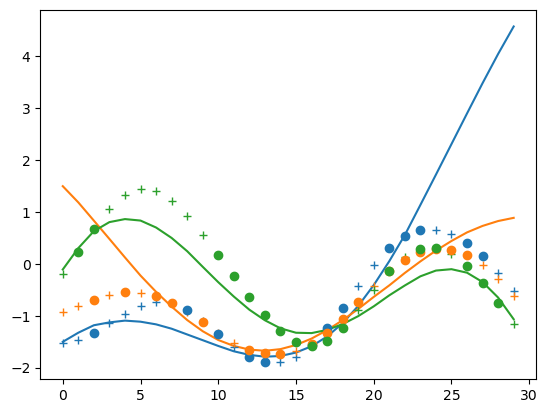

In [137]:
import matplotlib.pyplot as plt

i = 0
X_val_recon = gpuae.impute(dataset_val_nan_small, with_gp = True)
plt.plot(X_val_recon[i]);
plt.gca().set_prop_cycle(None)
plt.plot(dataset_val_nan['X_ori'][i],'+')
plt.gca().set_prop_cycle(None)
plt.plot(dataset_val_nan['X'][i],'o');

In [ ]:
from GP_regression_helpers import *

mse_obs, mse_hidden = plot_reconstruction_with_GP(X[::5], X_normalized[::5], gpvae, i = 0)

In [ ]:
plot_reconstruction_with_GP(torch.tensor(X[::5]).float(), torch.tensor(X_normalized[::5]).float(), gpvae, i = 0)
plot_reconstruction_with_GP(X[::5], X_normalized[::5], saits, i = 0)